# import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv(
    "train.csv"
)

In [3]:
# Convert date:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

# Create Product Features

In [4]:
product_sales = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales","sum"),

        Average_Order_Value=("Sales","mean"),

        Sales_Volatility=("Sales","std")
    )
    .reset_index()
)


product_sales

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280
5,Chairs,322822.7310,531.833165,551.180296
6,Copiers,146248.0940,2215.880212,3216.185499
7,Envelopes,16128.0460,65.032444,85.170691
8,Fasteners,3001.9600,14.027850,12.466864
9,Furnishings,89212.0180,95.823865,148.421490


# Growth Rate

In [5]:
yearly = (
    df.groupby(
        [
            "Sub-Category",
            df["Order Date"].dt.year
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [6]:
# Calculate growth:
yearly["Growth_Rate"] = (
    yearly.groupby(
        "Sub-Category"
    )["Sales"]
    .pct_change()
)

In [7]:
# Average:
growth = (
    yearly.groupby(
        "Sub-Category"
    )["Growth_Rate"]
    .mean()
    .reset_index()
)

In [8]:
# Merge:
product_features = product_sales.merge(
    growth,
    on="Sub-Category"
)

# Handle Missing Values

In [9]:
product_features.fillna(
    0,
    inplace=True
)


# Scaling

In [10]:
# remove name
X = product_features.drop(
    columns=[
        "Sub-Category"
    ]
)

In [11]:
# Scale:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)

# Elbow Method

In [12]:
scores=[]


for k in range(1,10):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(
        X_scaled
    )

    scores.append(
        model.inertia_
    )

C:\Users\Amita\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Amita\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Amita\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Amita\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Amita\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

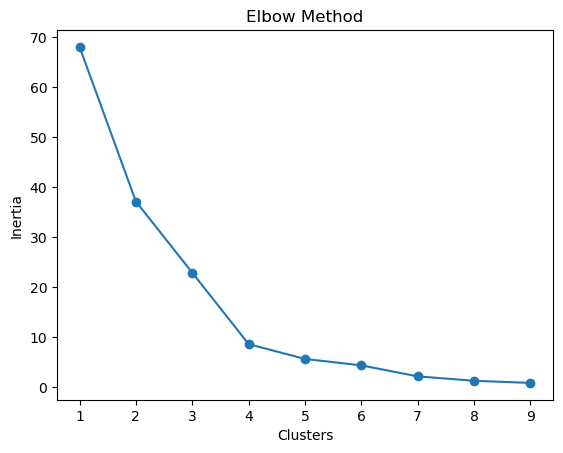

In [13]:
plt.plot(
    range(1,10),
    scores,
    marker="o"
)

plt.xlabel(
    "Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Elbow Method"
)
plt.savefig("charts/Elbow Method.png")
plt.show()

In [14]:
# Choose best K.
k=3

# Train KMeans

In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)


product_features["Cluster"] = kmeans.fit_predict(
    X_scaled
)

C:\Users\Amita\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# PCA Visualization

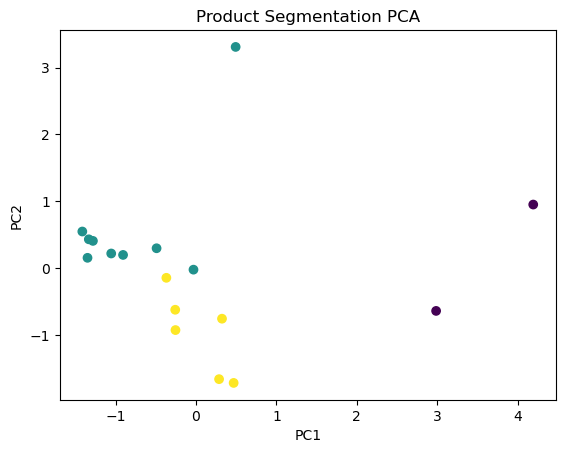

In [16]:
pca = PCA(
    n_components=2
)


components = pca.fit_transform(
    X_scaled
)


plt.scatter(
    components[:,0],
    components[:,1],
    c=product_features["Cluster"]
)


plt.title(
    "Product Segmentation PCA"
)


plt.xlabel(
    "PC1"
)


plt.ylabel(
    "PC2"
)
plt.savefig("charts/Product Segmentation PCA.png")
plt.show()

# Save Results

In [17]:
product_features.to_csv(
    "models/product_clusters.csv",
    index=False
)